In [1]:
import pandas as pd


In [2]:
from google.colab import files
uploaded = files.upload()


Saving raw_sales_dataset.csv to raw_sales_dataset.csv


In [3]:
df = pd.read_csv('raw_sales_dataset.csv')


In [4]:
print(df.head())
print(df.info())

   Order_ID Customer_Name Region     City         Category Sub_Category  \
0     25795         Deepa  North  Chennai       Technology      Binders   
1     10860          Arun  North   Mumbai        Furniture      Binders   
2     86820         Deepa  South  Chennai        Furniture       Phones   
3     64886         Deepa  South  Chennai        Furniture      Storage   
4     16265         Kumar   West  Chennai  Office Supplies      Storage   

  Product_Name    Sales  Quantity  Discount   Profit  Order_Date   Ship_Date  \
0    Product C  7021.86         2      0.39  1746.53  2022-08-17  2023-01-17   
1    Product A   322.67         6      0.45  1193.30  2023-10-02  2022-09-20   
2    Product C  8578.79         6      0.12  1045.09  2022-07-31  2023-01-20   
3    Product C  6974.53         6      0.10  1263.91  2024-03-07  2023-01-06   
4    Product D      NaN         8      0.00  1572.06  2024-03-01  2022-04-23   

  Payment_Mode  
0          UPI  
1         Cash  
2         Cash  


In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(0)
df['Customer_Name'] = df['Customer_Name'].fillna("Unknown")

# Convert date columns
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['Order_Date', 'Ship_Date'])

# Ensure numeric columns
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Final check
print("Cleaned Data Info:")
print(df.info())

# Save cleaned dataset
df.to_csv('sales_cleaned.csv', index=False)

print("✅ Data Cleaning Completed")

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       2500 non-null   int64         
 1   Customer_Name  2500 non-null   object        
 2   Region         2500 non-null   object        
 3   City           2500 non-null   object        
 4   Category       2500 non-null   object        
 5   Sub_Category   2500 non-null   object        
 6   Product_Name   2500 non-null   object        
 7   Sales          2500 non-null   float64       
 8   Quantity       2500 non-null   int64         
 9   Discount       2500 non-null   float64       
 10  Profit         2500 non-null   float64       
 11  Order_Date     2500 non-null   datetime64[ns]
 12  Ship_Date      2500 non-null   datetime64[ns]
 13  Payment_Mode   2500 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
memo

In [6]:
import pandas as pd

df = pd.read_csv('sales_cleaned.csv')

# ---------------- ANALYSIS ---------------- #

# Total Sales
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

# Total Profit
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

# Sales by Region
sales_region = df.groupby('Region')['Sales'].sum()
print("\nSales by Region:\n", sales_region)

# Profit by Category
profit_category = df.groupby('Category')['Profit'].sum()
print("\nProfit by Category:\n", profit_category)

# Top 5 Products
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Products:\n", top_products)

# Average Discount
avg_discount = df['Discount'].mean()
print("\nAverage Discount:", avg_discount)

Total Sales: 12643837.589473683
Total Profit: 1818205.71

Sales by Region:
 Region
East     3.289159e+06
North    3.060900e+06
South    3.071018e+06
West     3.222761e+06
Name: Sales, dtype: float64

Profit by Category:
 Category
Furniture          558563.03
Office Supplies    602092.71
Technology         657549.97
Name: Profit, dtype: float64

Top 5 Products:
 Product_Name
Product C    3.301963e+06
Product B    3.155353e+06
Product D    3.152537e+06
Product A    3.033985e+06
Name: Sales, dtype: float64

Average Discount: 0.25668


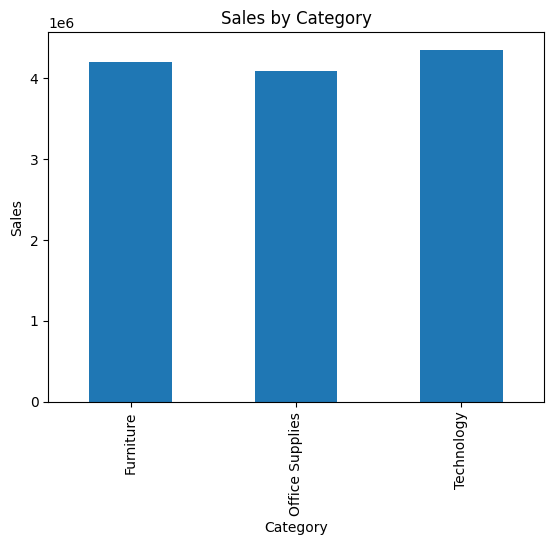

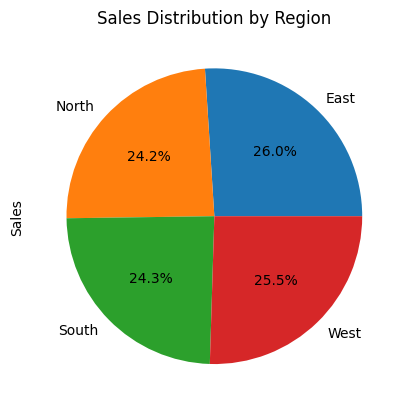

/tmp/ipykernel_391/2421997274.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Order_Date')['Profit'].resample('M').sum().plot()


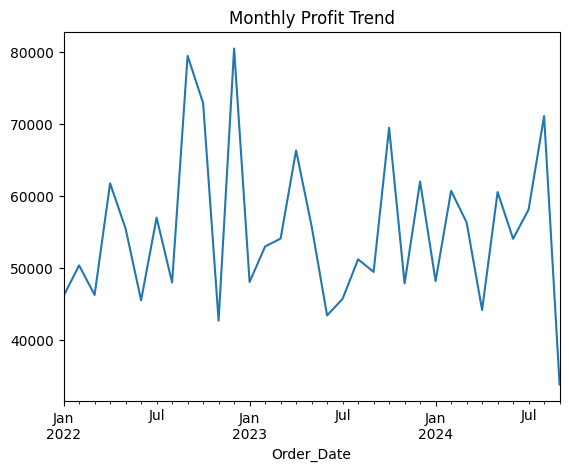

In [7]:
import matplotlib.pyplot as plt

# Sales by Category
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Region")
plt.show()

# Profit Trend Over Time
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.set_index('Order_Date')['Profit'].resample('M').sum().plot()
plt.title("Monthly Profit Trend")
plt.show()